# Edge Time-Series Analyses

This analysis extracts functional connectivity between different hippocampal subfields at specific timepoints during the task. Prior to this point, we used a GLM to fit stimulus-evoked responses with a canonical double-gamma hemodynamic response function (+ temporal derivative) for each trial and extracted the residuals of this model from the voxels in each subfield, stored in ./data/background_fmri/. 

This notebook can also be used to run these analyses on data without this GLM processing step (./data/masked_fmri/). 

Subject 51 is excluded from analyses involving the learning runs due to a bug in data acquisition.

**Procedure:**  
https://www.nature.com/articles/s41593-020-00719-y  
https://www.pnas.org/doi/abs/10.1073/pnas.2005531117  
1. average time series from hippocampal subfield ROIs during a particular run  
*output: 1 time vector for each ROI*
2. z-score the average time series of each ROI  
*output: 1 time vector for each ROI*
3. calculate elementwise product of z-scored timeseries from pairs of ROIs, producing edge time series  
*output: 1 time vector (cofluctuation) for each edge between ROIs*


## 0. Initialization

In [1]:
import warnings
import sys 
if not sys.warnoptions:
    warnings.filterwarnings("ignore", category=DeprecationWarning)
import os 
import random
import nibabel as nib
import numpy as np
import math
import pandas as pd

import scipy.io
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns 
from itertools import combinations

import statsmodels.api as sm
import statsmodels.formula.api as smf

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects import Formula

# Import R packages
nlme = importr('nlme')
base = importr('base')
rstats = importr('stats')
lme4 = importr('lme4')
sjstats = importr('sjstats')

from utils import *


In [2]:
subinfo = pd.read_csv('./data/subject_info.txt', sep="\t")
excl_thresh = int(np.round((21*3)*0.6)) # exclude inattentive responders
usable_subinfo = subinfo[subinfo.fmri_scenes_usable == 1].reset_index(drop=True)
usable_subinfo = usable_subinfo[usable_subinfo.encoded_pairs >= excl_thresh].reset_index(drop=True)
usable_subinfo = usable_subinfo[usable_subinfo.subid != 51].reset_index(drop=True) # subject 51 excluded from learning run analyses

subIDs = list(usable_subinfo.subid)
ctrl_subIDs = list(usable_subinfo[usable_subinfo.group == 0].subid)
stress_subIDs = list(usable_subinfo[usable_subinfo.group == 1].subid)

grpnum2name = {0: "Control", 1: "Stress"}
sub2grp = {usable_subinfo.iloc[i]["subid"]: grpnum2name[usable_subinfo.iloc[i]["group"]] for i in range(len(usable_subinfo))}
sub2grp_df = usable_subinfo[["subid", "group"]]
sub2grp_df["group"] = sub2grp_df["group"].apply(lambda x: grpnum2name[x])

groups = ["Control", "Stress"]

cmap = plt.get_cmap("plasma")

## 1. Data Loading Functions

In [3]:
masked_outdir = "./data/masked_fmri"
background_outdir = "./data/background_fmri"

def load_masked_data(subid, run, roi):
    """
    Loads in data for a given subject, run, and ROI
    Args:
        subid (int): subject ID
        run (string): scene run label
        roi (string): ROI name
    Returns:
        (np.array): masked voxel data with shape (TRs, voxels)
    """
    
    datafile = f'{masked_outdir}/{roi}/masked_{roi}_sub{subid}_{run}.npy'
    data = np.load(datafile)
    data_nonans = []
    for c in range(data.shape[1]):
        if not np.isnan(data[:,c]).any():
            data_nonans.append(data[:,c])
            
    data_nonans = np.array(data_nonans).T

    return data_nonans

# normalize BOLD data; within each run, each voxel should have mean 0 and std 1 across TRs
# bold_data_run should have dimensions (TRs, voxels)
def normalize_bold(bold_data_run):
    # exclude voxels with std 0
    bold_std = np.std(bold_data_run, axis=0)
    incl_voxs = np.argwhere(bold_std > 10e-5).T[0]
    
    bold_conservative = bold_data_run[:, incl_voxs]
    bold_cons_std = np.std(bold_conservative, axis=0)
    
    bold_normalized = (bold_conservative - np.mean(bold_conservative, axis = 0))/bold_cons_std
    return bold_normalized


def load_avg_backgroundresids(subid, run, roi, norm=True):
    background_file = f'{background_outdir}/{roi}/masked_{roi}_background_sub{subid}_{run}.npy'
    resids = np.load(background_file)[0]
    if norm:
        norm_resids = normalize_bold(resids)
    else:
        norm_resids = resids
    
    return np.mean(norm_resids, axis=1)


def load_avg_BOLD_timeseries(subid, run, roi):
    data = load_masked_data(subid, run, roi)
    norm_data = normalize_bold(data)

    return np.mean(norm_data, axis=1)


def normalize_timeseries(timeseries):
    return scipy.stats.zscore(timeseries, nan_policy='omit')


## 2. Edge Time Series Functions

In [4]:
def edge_time_series(subID, run, rois, use_background=False):
    '''
    Implements the edge time series procedure, returning a nodepair-by-nodepair eFC matrix for each timepoint in a given run for 1 subject
    
    Args:
        subID (int): subject ID
        run (string): run name
        rois (list(string)): list of ROI labels
    
    Returns:
        (np.array): nodepair-by-nodepair eFC matrix for each timepoint (shape timepoint x node x node)
        list(tuple): nodepair labels
    '''
    n_rois = len(rois)
    n_TRs = -1
    
    # STEP 1+2: average and z-score time series from hippocampal subfield ROIs during a particular run
    # output: 1 time vector for each ROI
    rois_timeseries = []
    for roi in rois:
        if use_background:
            cur_timeseries = load_avg_backgroundresids(subID, run, roi)
        else:
            cur_timeseries = load_avg_BOLD_timeseries(subID, run, roi) 
        cur_timeseries = normalize_timeseries(cur_timeseries)
        rois_timeseries.append(cur_timeseries)
        
        if n_TRs == -1:
            n_TRs = len(cur_timeseries)

    
    # STEP 3: calculate elementwise product of z-scored timeseries from pairs of ROIs, producing edge time series  
    # output: 1 time vector (cofluctuation) for each edge between ROIs
    edge_timeseries = np.empty((n_rois, n_rois, n_TRs))
    outlier_TRs = []
    
    for roi1 in range(n_rois):
        for roi2 in range(n_rois):
            cur_timeseries = rois_timeseries[roi1] * rois_timeseries[roi2]
            
            # extra step: identify outlier TRs
            outlier_TRs += list(np.where(scipy.stats.zscore(cur_timeseries) > 3)[0])
            
            edge_timeseries[roi1, roi2, :] = cur_timeseries

            
    # STEP 4: reshape this output to produce a FC matrix for each timepoint
    # output: 1 node-by-node matrix for each timepoint
    edge_timeseries = np.moveaxis(edge_timeseries, [0, 1, 2], [1, 2, 0])
    

    return edge_timeseries, outlier_TRs
    



In [5]:
def get_propagated_TRlabels(subid, run, exclude_noresp, nan_noresp, labeltype="gen", propagate=True, shift=3, numTRs=275, recogconf=0):
    '''
    Returns hemodynamic-shifted labels - one per TR
    Args:
        type (str): one of ["gen", "ABX", "category", "recog", "predictive"]
        
    Returns:
        list of labels (strings) associated with each TR, with 3TR hemodynamic shift built in 
    '''
    ABX = get_ABX_labels(subid, run, exclude_noresp=exclude_noresp, nan_noresp=nan_noresp)
    category = get_category_labels(subid, run, exclude_noresp=exclude_noresp, nan_noresp=nan_noresp)
    recog = get_recog_labels(subid, run, conf_thr=recogconf, exclude_noresp=exclude_noresp, nan_noresp=nan_noresp)
    stimTRs = get_stimulus_TRs(subid, run, exclude_noresp=exclude_noresp)
    l2g = labels2gencats(subid)
    
    out_labels = None

    gencats = [l2g[c] for c in category]
    allTR_labels = ['ISI']*numTRs
    for i in range(len(stimTRs)):
        if stimTRs[i] + shift >= numTRs:
            break
            
        if labeltype == "gen":
            allTR_labels[stimTRs[i]+shift] = gencats[i]
        elif labeltype == "ABX":
            allTR_labels[stimTRs[i]+shift] = ABX[i]
        elif labeltype == "category":
            allTR_labels[stimTRs[i]+shift] = category[i]
        elif labeltype == "recog":
            allTR_labels[stimTRs[i]+shift] = recog[i]
        elif labeltype == "predictive":
            if ABX[i] == "A":
                allTR_labels[stimTRs[i]+shift] = "P"
            elif ABX[i] == "B" or ABX[i] == "X":
                allTR_labels[stimTRs[i]+shift] = "N"

    if not propagate:
        out_labels = allTR_labels
    else:
        allTR_labels_propagate = ['ISI']*numTRs
        prev = "ISI"
        for i in range(len(allTR_labels)):
            label = allTR_labels[i]

            if label != "ISI": # if the current TR is a stimulus, update the current state to the current label
                prev = label

            # set the current label to the current state (prev)
            allTR_labels_propagate[i] = prev
        
        out_labels = allTR_labels_propagate
    
    return out_labels



def compute_ets(subIDs, runs, rois, conditions, condition_type, condition_propagate, shift=3, use_background=False):
    '''
    Args:
        conditions (list(string)): list of condition names; a subset of the condition labels output by get_propagated_TRlabels
        condition_type (string): labeltype to feed into get_propagated_TRlabels (one of ["gen", "ABX", "category"])
        condition_propagate (bool): whether or not to propagate these labels
        runs (list(string)): list of run names
        
    Returns:
        np.array with shape (subject, TR condition, node, node)
    '''
    
    ets = []
    # for each subject, compute the average ets matrix (node x node) across given runs in each TR condition
    for sub in subIDs:
        print(sub, end=',')
        runs_ets = []
        
        for run in runs:
            # compute the full timeseries of edge time series matrices for this subject, run, and set of ROIs (shape timepoint x node x node)
            cur_ets, outlier_TRs = edge_time_series(sub, run, rois, use_background=use_background)
            
            # get condition TRs for this subject and run
            TRlabels = np.array(get_propagated_TRlabels(sub, int(run[-1]), exclude_noresp=True, nan_noresp=False, labeltype=condition_type, propagate=condition_propagate, shift=shift))
            TRlabels = TRlabels[:cur_ets.shape[0]] #truncate the TRlabels to match the number of TRs collected during fMRI
            condition_TRs = [np.where(TRlabels == cond)[0] for cond in conditions]
            
            conds_ets = []
            
            for c in range(len(conditions)):
                cond_stimTRs = np.array(condition_TRs[c])
                cur_cond_ets = np.nanmean(cur_ets[cond_stimTRs], axis=0)
                conds_ets.append(cur_cond_ets)
            
            conds_ets = np.array(conds_ets) # shape cond x node x node
            runs_ets.append(conds_ets)
        
        runs_ets = np.array(runs_ets) # shape run x cond x node x node
        sub_ets = np.nanmean(runs_ets, axis=0) # mean over runs
        
        ets.append(sub_ets) 
    
    ets = np.array(ets) # shape sub x cond x node x node
    ets = np.moveaxis(ets, [0, 1, 2, 3], [1, 0, 2, 3]) # shape cond x sub x node x node
    
    return ets
        
    
def get_cond_TRs(sub, run, cond="A"):
    '''
    Outputs a DF containing all TRs associated with stimuli in a specified condition (A/B/X).
    
    Args:
        sub (int): subject ID number
        run (int): run number
        cond (str): one of ["A", "B", "X"]
    
    Returns:
        pandas DataFrame containing columns onsetTR (TR index) and cond (A/B/X)
    '''
    
    stimTRs = get_stimulus_TRs(sub, run, exclude_noresp=False)
    ABXlabels = get_ABX_labels(sub, run, exclude_noresp=False, nan_noresp=True)
    
    TR_df = pd.DataFrame({'onsetTR': stimTRs, 'cond': ABXlabels})
    out_df = TR_df[TR_df['cond'] == cond]
    
    return out_df


def get_ets_cond(runs, rois, relcond, TRshift=3, usebackground=True):
    '''
    For a given condition (A/B/X), returns a pandas dataframe containing information about the cofluctuation at relevant TRs. 
    
    Args:
        runs (list(int)): list of run numbers
        rois (list(str)): pair of ROIs
        relcond (str): one of ["A", "B", "X"]
        TRshift (int): number of TRs to shift to account for hemodynamic lag (default=3)
        usebackground (bool): whether to use cofluctuation computed using background signal with stimulus-evoked signal regressed out (default=True)
        
    Returns: 
        pd.DataFrame with columns ["onsetTR", "cond", "shiftedTR", "subid", "run", "roi1", "roi2", "ets", "group"]
    '''
    
    labeled_ets_df_all = []

    for sub in subIDs:
        for run in runs:
            ets_file = f"./midpoints/edgetimeseries/sub{sub}_runscene{run}_edgetimeseries_usebackground{usebackground}.csv"

            ets_df = pd.read_csv(ets_file)
            ets_df = ets_df.loc[(ets_df["roi1"] == rois[0]) & (ets_df["roi2"] == rois[1])].reset_index(drop = True).rename(columns={"TR": "shiftedTR"})

            condlabels = get_cond_TRs(sub, run, cond=relcond)
            condlabels["shiftedTR"] = condlabels["onsetTR"] + TRshift

            labeled_ets_df = pd.merge(condlabels, ets_df, on="shiftedTR", how="left").reset_index(drop=True)
            labeled_ets_df["run"] = [run]*len(labeled_ets_df)

            labeled_ets_df_all.append(labeled_ets_df)

    labeled_ets_df_all = pd.DataFrame(pd.concat(labeled_ets_df_all)).rename(columns={"subID": "subid"})
    
    labeled_ets_df_all = pd.merge(labeled_ets_df_all, sub2grp_df, on="subid", how="left")
    out_df = labeled_ets_df_all

    return out_df
    
    
def compute_recog_ets(subid, runs, rois, condition, recogconf=0, use_background=True):
    '''
    Args:
        runs (list(str)): list of string-style run names (e.g. 'scene2')
        rois (list(str)): pair of rois (e.g. ["CA1", "EC"])
        condition (str): one of ["remembered", "forgotten", "A", "B", "X", "Aremembered", "Aforgotten", "Bremembered", "Bforgotten", "Xremembered", "Xforgotten"]
        recogconf (int): confidence threshold for recognition judgments (default=0; correct response counts as "remembered" regardless of confidence)
        usebackground (bool): whether to use cofluctuation computed using background signal with stimulus-evoked signal regressed out (default=True)
    '''
    
    recog_conds = ["remembered", "forgotten"]
    ABX_conds = ["A", "B", "X"]
    ABXrecog_conds = ["Aremembered", "Aforgotten", "Bremembered", "Bforgotten", "Xremembered", "Xforgotten"]
    
    cond_ets = []
    
    for run in runs:
        run_num = int(run[-1])
        ets, _ = edge_time_series(subid, run, rois, use_background=use_background)
        
        recog_TRlabs = get_propagated_TRlabels(subid, run_num, exclude_noresp=True, nan_noresp=False, labeltype="recog", propagate=False, shift=3, numTRs=ets.shape[0], recogconf=recogconf)
        ABX_TRlabs = get_propagated_TRlabels(subid, run_num, exclude_noresp=True, nan_noresp=False, labeltype="ABX", propagate=False, shift=3, numTRs=ets.shape[0], recogconf=recogconf)
        ABX_recog_TRlabs = [ABX_TRlabs[i] + recog_TRlabs[i] for i in range(ets.shape[0])]
        
        if condition in recog_conds:
            TRlabs = recog_TRlabs
        elif condition in ABX_conds:
            TRlabs = ABX_TRlabs
        elif condition in ABXrecog_conds:
            TRlabs = ABX_recog_TRlabs
        
        cond_TRs = np.where(np.array(TRlabs) == condition)[0]
        #cond_ets.append(np.nanmean(ets[cond_TRs,:,:], axis=0))
        cond_ets.append(ets[cond_TRs,:,:])
    
    cond_ets = np.concatenate(cond_ets, axis=0)
    cond_ets = np.nanmean(cond_ets, axis=0) # mean over runs
    
    return cond_ets


## 3. Save edge timeseries for each subject and run

In [6]:
rois = ['CA1', 'CA23', 'DG', 'EC']
runs = ['scene2', 'scene3', 'scene4']
use_background = True
use_saved = True

for sub in subIDs:
    print(sub, end=',')
    for run in runs:
        outcsv = f'./midpoints/edgetimeseries/sub{sub}_run{run}_edgetimeseries_usebackground{use_background}.csv'
        
        if not use_saved or not os.path.isfile(outcsv):
            subrun_ets_df = {'subID': [], 'run': [], 'roi1': [], 'roi2': [], 'TR': [], 'ets': []}
            ets, _ = edge_time_series(sub, run, rois, use_background=use_background)

            for roi1, roi2 in combinations(np.arange(len(rois)), 2):
                subrun_ets_df['subID'] += [sub]*ets.shape[0]
                subrun_ets_df['run'] += [run]*ets.shape[0]
                subrun_ets_df['roi1'] += [rois[roi1]]*ets.shape[0]
                subrun_ets_df['roi2'] += [rois[roi2]]*ets.shape[0]
                subrun_ets_df['TR'] += list(np.arange(ets.shape[0]))
                subrun_ets_df['ets'] += list(ets[:, roi1, roi2])

            subrun_ets_df = pd.DataFrame(subrun_ets_df)
            subrun_ets_df.to_csv(outcsv, index=False)
            
                

2,3,4,5,7,8,10,13,14,15,17,20,21,23,24,28,29,30,31,32,33,34,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,68,69,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,98,100,101,103,104,105,106,

## 4. Save momentary cofluctuation during A items

In [7]:
# save out trial-level A cofluctuation between all pairs of ROIs in MSP and TSP during learning runs
runs = [2, 3, 4]
roipairs = [["CA1", "EC"], ["CA1", "CA23"], ["CA23", "DG"], ["CA23", "EC"], ["DG", "EC"]]
relcond = "A"
usebackground = True
overwrite = False

# loop through all pairs of ROIs
for rois in roipairs:
    if rois == ["CA1", "EC"]:
        roiname = "MSP"
    else:
        roiname = "-".join(rois)

    runname = "runs" + "".join([str(r) for r in runs])

    # match scene category labels to shifted TRs for all subjects and runs
    catlabel_df_all = []

    for sub in subIDs:
        for run in runs:
            catlabel_df = pd.DataFrame({"shiftedTR": np.array(get_stimulus_TRs(sub, run, exclude_noresp=True)) + 3, 
                                        "category": get_category_labels(sub, run, exclude_noresp=True)})

            catlabel_df["subid"] = [sub]*len(catlabel_df)
            catlabel_df["run"] = [run]*len(catlabel_df)

            catlabel_df_all.append(catlabel_df)

    catlabel_df_all = pd.concat(catlabel_df_all)

    # get trialwise edgetimeseries data for all subjects
    outfile = f'./midpoints/cofluctuation/edgetimeseries_{relcond}_trialwise_{runname}_{roiname}_usebackground{usebackground}.csv'

    if overwrite or not os.path.isfile(outfile):
        ets_cond_df = get_ets_cond(runs, rois, relcond, TRshift=3, usebackground=usebackground)

        # join edgetimeseries data with category labels
        ets_cond_df = pd.merge(ets_cond_df, catlabel_df_all, on=["subid", "run", "shiftedTR"], how="left")

        # save out resulting dataframe
        ets_cond_df.to_csv(outfile, index=False)
            

## 5. Compare cofluctuation during remembered vs forgotten A items

In [8]:
def get_ets_recog_df(subIDs, rois, cond, runs=[2, 3, 4], recogconf=0, usebackground=True, overwrite=False):
    '''
    Args:
        subIDs (list(int)): list of subject ID numbers
        rois (list(str)): pair of ROIs
        cond (str): one of ["A", "B", "X"]
        runs (list(int)): list of run numbers
        recogconf (int): confidence threshold for recognition judgments (default=0; correct response counts as "remembered" regardless of confidence)
        usebackground (bool): whether to use cofluctuation computed using background signal with stimulus-evoked signal regressed out (default=True)
        overwrite (bool): whether to recompute previously generated results
        
    Returns:
        pandas DataFrame with columns ["subid", "recog", "ets", "group"]
    '''
    
    if rois == ["CA1", "EC"]:
        roiname = "MSP"
    else:
        roiname = '-'.join(rois)

    runstrs = [f'scene{r}' for r in runs]
    runname = "runs" + "".join([str(r) for r in runs])
    
    outfile = f"./midpoints/cofluctuation/edgetimeseries_{cond}_recog_{runname}_{roiname}_conf{recogconf}_usebackground{use_background}.csv"
    
    if overwrite or not os.path.isfile(outfile):
        ets_recog_df = {"subid": [], "recog": [], "ets": []}
        for sub in subIDs:
            for recogcond in ["remembered", "forgotten"]:
                cur_ets = compute_recog_ets(sub, runstrs, rois, f"{cond}{recogcond}", recogconf=recogconf, use_background=use_background)[1, 0]

                ets_recog_df["subid"].append(sub)
                ets_recog_df["recog"].append(recogcond)
                ets_recog_df["ets"].append(cur_ets)


        ets_recog_df = pd.DataFrame(ets_recog_df)
        ets_recog_df = pd.merge(ets_recog_df, sub2grp_df, on="subid", how="left").reset_index(drop=True)
        ets_recog_df.to_csv(outfile, index=False)
    
    else:
        ets_recog_df = pd.read_csv(outfile)
    
    return ets_recog_df
    

### Visualize subsequent memory cofluctuation for MSP (Figure 4A, Supplemental Figure S7A)
By default, this code visualizes and computes statistics for MSP (CA1-EC) and using background signal (after regressing out stimulus-evoked signal), corresponding to Figure 4A.  
To run the same analysis along a different connection, change the `rois` variable (ROIs should be in alphabetical order). Supplemental Figure S7A is composed of the results of this analysis from the following pairs of ROIs: ['DG', 'EC'], ['CA23', 'EC'], ['CA23', 'DG'], ['CA1', 'CA23'], ['CA1', 'EC'].


Control
ets ~ recog + (1 | subid)

             numDF  denDF    F-value       p-value
(Intercept)      1   41.0  68.099549  2.992591e-10
recog            1   41.0   5.327972  2.610516e-02
       partial.etasq  statistic
recog          0.086      5.328
1                NaN        NaN

Stress
ets ~ recog + (1 | subid)

             numDF  denDF    F-value       p-value
(Intercept)      1   44.0  95.087511  1.444400e-12
recog            1   44.0   2.162975  1.484865e-01
       partial.etasq  statistic
recog           0.03      2.163
1                NaN        NaN

Both
ets ~ group * recog + (1 | subid)

             numDF  denDF     F-value   p-value
(Intercept)      1   85.0  159.302762  0.000000
group            1   85.0    0.088611  0.766676
recog            1   85.0    0.240790  0.624901
group:recog      1   85.0    7.108958  0.009180
             partial.etasq  statistic
group                0.001      0.089
recog                0.002      0.241
group:recog          0.054      7.10

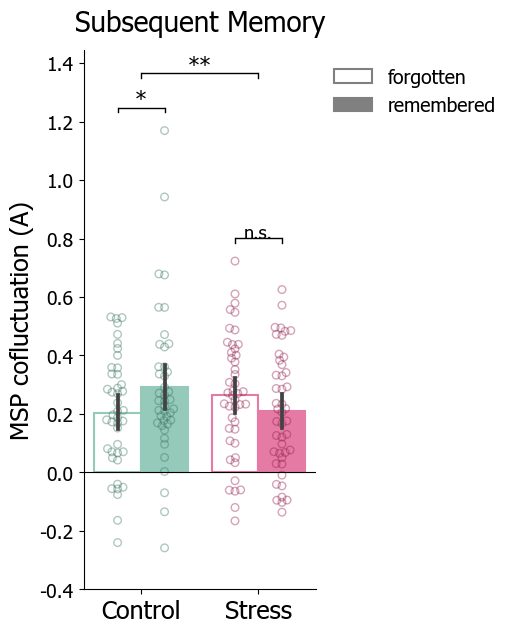

In [9]:
rois = ["CA1", "EC"]
cond = 'A'
recogvars = ["forgotten", "remembered"]

if rois == ["CA1", "EC"]:
    roiname = "MSP"
else:
    roiname = '-'.join(rois)

ets_recog_df = get_ets_recog_df(subIDs, rois, cond)

fig, ax = plt.subplots(1, 1, figsize=(3, 7))
sns.barplot(ax=ax, data=ets_recog_df, x="group", y="ets", hue="recog", order=groups, hue_order=recogvars)
sns.swarmplot(ax=ax, data=ets_recog_df, x="group", y="ets", hue="recog", order=groups, hue_order=recogvars, dodge=True, palette=['gray', 'gray'], alpha=0, legend=False, s=4)
for groupi in range(len(groups)):
    for recogi in range(len(recogvars)):
        i = groupi*len(recogvars) + recogi
        x_data, y_data = ax.collections[i].get_offsets().T

        ax.scatter(x_data, y_data, color="None", s=30, alpha=0.4, edgecolor=dark_group_colors[groupi], linewidth=1)
    
# add barstyle
for i, bar in enumerate(ax.patches):
    if i < len(groups)*len(recogvars):
        #bar.set_hatch(hatches[i//len(groups)])
        if i//len(groups) == 0:
            bar.set_color('white')
        else:
            bar.set_color(group_colors[i%len(groups)])
        bar.set_edgecolor(group_colors[i%len(groups)])
        bar.set_linewidth(1.5)
            
sns.despine()


########################################
# add significance stars and bars
########################################

# add significances - within group
yshift = np.diff(ax.get_ylim())[0]*0.05
barxs = np.reshape([line.get_data()[0][0] for line in ax.get_lines()[:len(groups)*len(recogvars)]], (2, 2)).T
max_stary = 0

for groupi, group in zip(np.arange(len(groups)), groups):
    print(f'\n{group}')
    grp_df = ets_recog_df[ets_recog_df["group"] == group]
    ingrp_anova, ingrp_effsize = r_lme(grp_df, "ets ~ recog", "~ 1 | subid", effsize=True)
    print(ingrp_anova)
    print(ingrp_effsize[["partial.etasq", "statistic"]])
    pval = ingrp_anova["p-value"]["recog"]
    star = pval2star(pval)

    if pval > 0.05 and pval < 0.07:
        star = "~"
        starsize=16
    elif star == '':
        star = "n.s."
        starsize=13
    else:
        starsize=16
    
    linex = barxs[groupi]
    starx = np.mean(linex)
    stary = np.max(grp_df["ets"])+yshift
    if stary > max_stary:
        max_stary = stary
    
    ax.text(x=starx, y=stary, s=star, ha="center", fontsize=starsize)
    ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color="black", linewidth=1)
    ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color="black", linewidth=1, capstyle="projecting")
    ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color="black", linewidth=1, capstyle="projecting")

# add significance - between group interaction
print("\nBoth")
btngrp_anova, btngrp_effsize = r_lme(ets_recog_df, "ets ~ group*recog", "~ 1 | subid", effsize=True)
print(btngrp_anova)
print(btngrp_effsize[["partial.etasq", "statistic"]])
pval = btngrp_anova["p-value"]["group:recog"]

star = pval2star(pval)
if star != '':
    linex = np.mean(barxs, axis=1)
    starx = np.mean(linex)
    stary = np.max([np.max(ets_recog_df["ets"])+yshift, max_stary + yshift*1.5])

    ax.text(x=starx, y=stary, s=star, horizontalalignment="center", fontsize=16)
    ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color="black", linewidth=1)
    ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color="black", linewidth=1, capstyle="projecting")
    ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color="black", linewidth=1, capstyle="projecting")

    
legend_elements = [Patch(facecolor="white", edgecolor='gray', linewidth=1.5, label=recogvars[0]), 
                   Patch(facecolor="gray", edgecolor='gray', linewidth=1.5, label=recogvars[1])]

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=14)

ax.axhline(y=0, linewidth=0.8, color='k')
ax.set_ylabel(f"{roiname} cofluctuation (A)", fontsize=18)
ax.set_xlabel("")
ax.set_xticklabels(groups, fontsize=18)

if roiname != "MSP":
    yticks = np.arange(-0.6, 1.41, 0.2)
else:
    yticks = np.arange(-0.4, 1.41, 0.2)
ytickstrs = ytickstrs = [f"{yt:.01f}" for yt in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(ytickstrs, fontsize=14)
try:
    ax.set_ylim([yticks[0], stary + yshift])
except:
    ax.set_ylim([yticks[0], yticks[-1]])

ax.set_title(f"Subsequent Memory", fontsize=20, y=1.02)
plt.show()


### Subsequent memory cofluctuation: Effect of learning-concurrent cortisol

In [10]:
cort_df = pd.read_csv(f'./midpoints/summary/Day1_cortisol_react.csv')[["subID", "cort_react"]].rename(columns={"subID": "subid"})
ets_recog_cort_df = pd.merge(cort_df, ets_recog_df, on=["subid"], how="left").dropna()

# LME both groups + cortisol
print("Both groups")
print(r_lme(ets_recog_cort_df, formula="ets ~ recog * cort_react * group", random_formula="~ 1 | subid"))

# LME single group
for group in groups:
    print(f'\n{group}:')
    print(r_lme(ets_recog_cort_df[ets_recog_cort_df["group"] == group].reset_index(drop=True), formula="ets ~ recog * cort_react", random_formula="~ 1 | subid"))
    

Both groups
                        numDF  denDF     F-value   p-value
(Intercept)                 1   70.0  135.699067  0.000000
recog                       1   70.0    0.204640  0.652400
cort_react                  1   70.0    0.110615  0.740439
group                       1   70.0    0.049827  0.824014
recog:cort_react            1   70.0    3.046857  0.085281
recog:group                 1   70.0    3.414076  0.068868
cort_react:group            1   70.0    0.020461  0.886668
recog:cort_react:group      1   70.0    0.058384  0.809775

Control:
                  numDF  denDF    F-value       p-value
(Intercept)           1   33.0  48.554185  5.761564e-08
recog                 1   33.0   4.728824  3.693172e-02
cort_react            1   33.0   0.010288  9.198242e-01
recog:cort_react      1   33.0   0.071116  7.913785e-01

Stress:
                  numDF  denDF    F-value       p-value
(Intercept)           1   37.0  99.668610  4.800382e-12
recog                 1   37.0   1.977800  1.6

### Subsequent memory cofluctuation: Effect of scanner

In [11]:
bw_first_sub = 56 # subjects before this number were at BIC, this subject and onward at Brainworks

ets_recog_scanner_df = ets_recog_df.copy()
ets_recog_scanner_df["scanner"] = ets_recog_scanner_df["subid"].apply(lambda x: "BIC" if x < bw_first_sub else "Brainworks")

# scanner effects - both groups
print("Both groups:")
print(r_lme(ets_recog_scanner_df, formula=f"ets ~ group*recog*scanner", random_formula="~ 1 | subid"))

# scanner effects - one group
for group in groups:
    grp_df = ets_recog_scanner_df[ets_recog_scanner_df["group"] == group]
    print(f'\n{group}:')
    print(r_lme(grp_df, formula=f"ets ~ recog*scanner", random_formula="~ 1 | subid"))


Both groups:
                     numDF  denDF     F-value   p-value
(Intercept)              1   83.0  157.944078  0.000000
group                    1   83.0    0.087856  0.767662
recog                    1   83.0    0.236273  0.628192
scanner                  1   83.0    1.210672  0.274380
group:recog              1   83.0    6.975595  0.009871
group:scanner            1   83.0    0.064356  0.800367
recog:scanner            1   83.0    0.291853  0.590482
group:recog:scanner      1   83.0    0.113572  0.736965

Control:
               numDF  denDF    F-value       p-value
(Intercept)        1   40.0  67.699613  3.890530e-10
recog              1   40.0   5.250050  2.729056e-02
scanner            1   40.0   0.759215  3.887742e-01
recog:scanner      1   40.0   0.400370  5.304990e-01

Stress:
               numDF  denDF    F-value       p-value
(Intercept)        1   43.0  93.908911  2.220890e-12
recog              1   43.0   2.114934  1.531292e-01
scanner            1   43.0   0.454624  

## 6. Compare cofluctuation during A items in learned vs not-learned pairs

In [12]:
def threewaysplit(x):
    out = None
    if x > 0.5:
        out = "above"
    elif x == 0.5:
        out = "chance"
    elif x < 0.5:
        out = "below"

    return out


def get_ABX2gencat(subIDs):
    AB = pd.read_csv("./data/behavior/AB.csv", sep='\t')
    X = pd.read_csv("./data/behavior/X.csv", sep='\t')
    
    pair_categs = {'A': 3, 'B': 3, 'X': 6}
    
    ABX = {'subID': []}
    
    for k in pair_categs.keys():
        for i in range(pair_categs[k]):
            ABX[f'{k}{i+1}'] = []
    
    for s in subIDs:
        ABX['subID'].append(s)
        
        cur_AB = AB[AB["subid"] == s]
        cur_X = X[X["subid"] == s]
        
        for i in range(len(cur_AB)):
            ABX[f'A{i+1}'].append(cur_AB.iloc[i]['A'])
            ABX[f'B{i+1}'].append(cur_AB.iloc[i]['B'])
    
        for i in range(len(cur_X)):
            ABX[f'X{i+1}'].append(cur_X.iloc[i]['X'])
    
    ABX = pd.DataFrame(ABX)
    
    ABX = ABX.melt(id_vars = 'subID', value_vars = list(ABX.columns[1:]))
    ABX = ABX.rename(columns={'variable': 'gencat', 'value': 'categ'})

    return ABX


def behavfamil_pairwise_stats(subIDs):
    '''
    Args:
        subIDs (list(int)): list of subject ID numbers
    '''

    famil = pd.read_csv('./data/behavior/familiarityData.csv', sep='\t')
    famil = famil[np.isin(famil["subID"], subIDs)]
    ABX = get_ABX2gencat(subIDs)
    
    famil = famil[["subID", "probed", "cond", "group", "acc"]].rename(columns = {"probed": "categ"})
    famil = pd.merge(famil, ABX, on=["subID", "categ"], how="left")
    famil["gencat1"] = famil["gencat"].apply(lambda x: x[0])
    famil["pairnum"] = famil["gencat"].apply(lambda x: x[1])

    assert list(famil["cond"]) == list(famil["gencat1"])
    
    famil = famil[["subID", "pairnum", "group", "acc"]]
            
    familacc = famil.groupby(by=["subID", "group", "pairnum"]).mean().reset_index()
    familacc = familacc.rename(columns = {"acc": "familacc"})
    familacc["group"] = familacc["group"].apply(lambda x: "Control" if x == 0 else "Stress")

    return familacc


def get_ets_famil_df(subIDs, rois, cond, binarize, runs=[2,3,4], usebackground=True, overwrite=False):
    '''
    Args:
        subIDs (list(int)): list of subject ID numbers
        rois (list(str)): pair of ROIs in alphabetical order
        cond (str): one of ["A", "B", "X"]
        binarize (bool): if True, binarizes continuous familiarity strength values to above or below chance
        runs (list(int)): list of run numbers
        usebackground (bool): whether to use cofluctuation computed using background signal with stimulus-evoked signal regressed out (default=True)
        overwrite (bool): whether to recompute previously generated results
    '''

    if rois == ["CA1", "EC"]:
        roiname = "MSP"
    else:
        roiname = '-'.join(rois)
    runstr = ''.join([str(i) for i in runs])
    
    outfile = f"./midpoints/cofluctuation/edgetimeseries_{cond}_famil_{runstr}_{roiname}_binarize{binarize}_usebackground{use_background}.csv"
    
    if overwrite or not os.path.isfile(outfile):
        # get pairnum mapping
        ABX = get_ABX2gencat(subIDs)

        # get pair familiarity data
        famildf = behavfamil_pairwise_stats(subIDs)

        # load in cofluctuation for the specified cond
        df_path = f"./midpoints/cofluctuation/edgetimeseries_{cond}_trialwise_runs{runstr}_{roiname}_usebackground{usebackground}.csv"
        df = pd.read_csv(df_path).rename(columns={"subid": "subID", "category": "categ"}).drop(columns=["roi1", "roi2", "shiftedTR"])
        df = df[np.isin(df["subID"], subIDs)].drop(columns="cond").reset_index(drop=True)

        # merge cofluctuation with pairnum information
        mergedf = pd.merge(df, ABX, on=["subID", "categ"], how="left")
        mergedf["pairnum"] = mergedf["gencat"].apply(lambda x: x[-1])
        mergedf = mergedf.drop(columns=["categ", "gencat", "run"]).groupby(["subID", "group", "pairnum"]).mean().reset_index()

        # merge with familiarity-per-pair information
        ets_famil_df = pd.merge(mergedf, famildf, on=["subID", "group", "pairnum"], how="left").reset_index(drop=True)

        # redefine familacc relative to chance
        if binarize:
            ets_famil_df["familacc"] = ets_famil_df['familacc'].apply(threewaysplit)
            ets_famil_df = ets_famil_df[ets_famil_df["familacc"] != "chance"]
            familacc_conds = ["below", "above"]
            below_familcond = "below"
            above_familcond = "above"

        ets_famil_df = ets_famil_df[np.isin(ets_famil_df["subID"], subIDs)].rename(columns={"subID": "subid"})[["subid", "pairnum", "familacc", "ets", "group"]].reset_index(drop=True)
        ets_famil_df.to_csv(outfile, index=False)
        
    else:
        ets_famil_df = pd.read_csv(outfile)

    return ets_famil_df


### Visualize learned/not-learned cofluctuation for MSP (Figure 4B, Supplemental Figure S7B)
By default, this code visualizes and computes statistics for MSP (CA1-EC) and using background signal (after regressing out stimulus-evoked signal), corresponding to Figure 4B.  
To run the same analysis along a different connection, change the `rois` variable (ROIs should be in alphabetical order). Supplemental Figure S7B is composed of the results of this analysis from the following pairs of ROIs: ['DG', 'EC'], ['CA23', 'EC'], ['CA23', 'DG'], ['CA1', 'CA23'], ['CA1', 'EC'].


Control:
ets ~ familacc + (1 | subid)

             numDF  denDF    F-value       p-value
(Intercept)      1   49.0  71.909589  3.559197e-11
familacc         1   49.0   0.507276  4.796982e-01
          partial.etasq  statistic
familacc          0.007      0.507
1                   NaN        NaN

Stress:
ets ~ familacc + (1 | subid)

             numDF  denDF    F-value       p-value
(Intercept)      1   62.0  78.476407  1.299183e-12
familacc         1   62.0   4.747021  3.315889e-02
          partial.etasq  statistic
familacc          0.048      4.747
1                   NaN        NaN

Both: 
ets ~ familacc * group + (1 | subid)

                numDF  denDF     F-value   p-value
(Intercept)         1  111.0  149.479387  0.000000
familacc            1  111.0    0.762977  0.384284
group               1   85.0    1.161748  0.284153
familacc:group      1  111.0    3.691303  0.057261
                partial.etasq  statistic
familacc                0.005      0.763
group                 

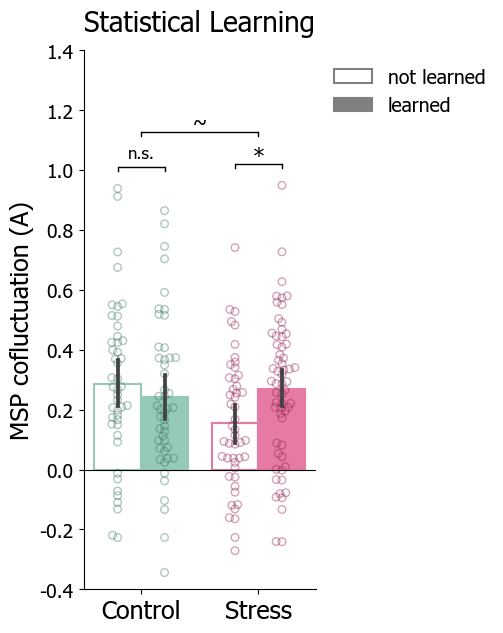

In [13]:
np.random.seed(0)

# visualization parameters
rois = ["CA1", "EC"]
cond = 'A'
familacc_conds = ["below", "above"]

if rois == ["CA1", "EC"]:
    roiname = "MSP"
else:
    roiname = '-'.join(rois)
    
# get dataframe mapping learned/not-learned for each participant to mean cofluctuation
ets_famil_df = get_ets_famil_df(subIDs, rois, cond=cond, binarize=True)

# visualize
fig, ax = plt.subplots(1, 1, figsize=(3, 7))
sns.barplot(ax=ax, data=ets_famil_df, x="group", y="ets", hue="familacc", palette="mako", order=groups, hue_order=familacc_conds)
sns.swarmplot(ax=ax, data=ets_famil_df, x="group", y="ets", hue="familacc", palette="mako", order=groups, hue_order=familacc_conds, dodge=True, alpha=0, s=4)

# add pointstyle
for groupi in range(len(groups)):
    for famili in range(len(familacc_conds)):
        i = groupi*len(familacc_conds) + famili
        x_data, y_data = ax.collections[i].get_offsets().T

        ax.scatter(x_data, y_data, color="None", s=30, alpha=0.4, edgecolor=dark_group_colors[groupi], linewidth=1)

# add barstyle
for i, bar in enumerate(ax.patches):
    if i < len(groups)*len(familacc_conds):
        if i//len(groups) == 0:
            bar.set_color('white')
        else:
            bar.set_color(group_colors[i%len(groups)])
        bar.set_edgecolor(group_colors[i%len(groups)])
        bar.set_linewidth(1.5)

# define legend elements
legend_elements = [Patch(facecolor="white", edgecolor='gray', linewidth=1.5, label='not learned'), 
                   Patch(facecolor="gray", edgecolor='gray', linewidth=1.5, label='learned')]


ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=14)


########################################
# add significance stars and bars
########################################

barxs = np.reshape([line.get_data()[0][0] for line in ax.get_lines()[:len(familacc_conds)*len(groups)]], (len(familacc_conds), len(groups))).T
barys = np.reshape([line.get_data()[1][1] for line in ax.get_lines()[:len(familacc_conds)*len(groups)]], (len(familacc_conds), len(groups))).T
shifty = np.diff(ax.get_ylim())*0.05

# add significance within groups
for groupi, group in zip(np.arange(len(groups)), groups):
    print(f'\n{group}:')
    grp_df = ets_famil_df[ets_famil_df["group"] == group].reset_index(drop=True)
    ingrp_anova, ingrp_effsize = r_lme(grp_df, formula="ets ~ familacc", random_formula = "~ 1 | subid", effsize=True)
    pval = ingrp_anova["p-value"]["familacc"]
    
    print(ingrp_anova)
    print(ingrp_effsize[["partial.etasq", "statistic"]])

    star = pval2star(pval)
    linex = barxs[groupi]
    starx = np.mean(linex)
    stary = np.max(grp_df["ets"]) + shifty

    ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
    ax.vlines(x=linex[0], ymin=stary-shifty*0.2, ymax=stary, color='k', linewidth=1, capstyle='projecting')
    ax.vlines(x=linex[1], ymin=stary-shifty*0.2, ymax=stary, color='k', linewidth=1, capstyle='projecting')

    if star != '':
        ax.text(x=starx, y=stary, s=star, color='k', fontsize=16, ha='center')
    else:
        ax.text(x=starx, y=stary + shifty*0.3, s='n.s.', color='k', fontsize=12, ha='center', va='bottom')
    
# add significance for both groups
print(f'\nBoth: ')
btngrp_anova, btngrp_effsize = r_lme(ets_famil_df, formula="ets ~ familacc * group", random_formula="~ 1 | subid", effsize=True)
btngrp_pval = btngrp_anova["p-value"]["familacc:group"]
print(btngrp_anova)
print(btngrp_effsize[["partial.etasq", "statistic"]])


if btngrp_pval < 0.06:
    linex = np.mean(barxs, axis=1)
    starx = np.mean(linex)
    stary = np.max(ets_famil_df["ets"]) + shifty*2.5

    ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
    ax.vlines(x=linex[0], ymin=stary-shifty*0.2, ymax=stary, color='k', linewidth=1, capstyle='projecting')
    ax.vlines(x=linex[1], ymin=stary-shifty*0.2, ymax=stary, color='k', linewidth=1, capstyle='projecting')
    
    if btngrp_pval <= 0.05:
        star = pval2star(btngrp_pval)
        ax.text(x=starx, y=stary, s=star, color='k', ha='center', fontsize=16)
    else:
        star = '~'
        ax.text(x=starx, y=stary, s=star, color='k', ha='center', fontsize=14, va='bottom')

        
########################################
# aesthetics
########################################
ax.set_title("Statistical Learning", fontsize=20, y=1.02)
ax.axhline(y=0, linewidth=0.8, color='k')
ax.set_xlabel("")
ax.set_xticklabels(groups, fontsize=18)
ax.set_ylabel(f"{roiname} cofluctuation ({cond})", fontsize=18)
yticks = np.arange(-0.4, 1.41, 0.2)
ytickstrs = [f"{yt:.01f}" for yt in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(ytickstrs, fontsize=14)
ax.set_ylim([yticks[0], yticks[-1]])
sns.despine()

plt.show()


### Statistical learning cofluctuation: Effect of learning-concurrent cortisol

In [14]:
cort_df = pd.read_csv(f'./midpoints/summary/Day1_cortisol_react.csv')[["subID", "cort_react"]].rename(columns={"subID": "subid"})
ets_famil_cort_df = pd.merge(cort_df, ets_famil_df, on=["subid"], how="left").dropna()

# LME both groups + cortisol
print("Both groups")
print(r_lme(ets_famil_cort_df, formula="ets ~ familacc * cort_react * group", random_formula="~ 1 | subid"))

# LME single group
for group in groups:
    print(f'\n{group}:')
    print(r_lme(ets_famil_cort_df[ets_famil_cort_df["group"] == group].reset_index(drop=True), formula="ets ~ familacc * cort_react", random_formula="~ 1 | subid"))
    

Both groups
                           numDF  denDF     F-value   p-value
(Intercept)                    1   95.0  128.432829  0.000000
familacc                       1   95.0    0.188428  0.665213
cort_react                     1   70.0    0.000403  0.984036
group                          1   70.0    0.481845  0.489885
familacc:cort_react            1   95.0    1.579584  0.211902
familacc:group                 1   95.0    1.945941  0.166278
cort_react:group               1   70.0    0.105409  0.746401
familacc:cort_react:group      1   95.0    0.005861  0.939136

Control:
                     numDF  denDF    F-value       p-value
(Intercept)              1   40.0  53.541137  6.808899e-09
familacc                 1   40.0   1.060019  3.093965e-01
cort_react               1   33.0   0.000004  9.984730e-01
familacc:cort_react      1   40.0   0.028391  8.670422e-01

Stress:
                     numDF  denDF    F-value       p-value
(Intercept)              1   55.0  78.430669  3.592682e-1

### Statistical learning cofluctuation: Effect of scanner

In [15]:
bw_first_sub = 56 # subjects before this number were at BIC, this subject and onward at Brainworks

ets_famil_scanner_df = ets_famil_df.copy()
ets_famil_scanner_df["scanner"] = ets_famil_scanner_df["subid"].apply(lambda x: "BIC" if x < bw_first_sub else "Brainworks")

# scanner effects - both groups
print("Both groups:")
print(r_lme(ets_famil_scanner_df, formula=f"ets ~ group*familacc*scanner", random_formula="~ 1 | subid"))

# scanner effects - one group
for group in groups:
    grp_df = ets_famil_scanner_df[ets_famil_scanner_df["group"] == group]
    print(f'\n{group}:')
    print(r_lme(grp_df, formula=f"ets ~ familacc*scanner", random_formula="~ 1 | subid"))


Both groups:
                        numDF  denDF     F-value   p-value
(Intercept)                 1  109.0  147.465346  0.000000
group                       1   83.0    1.074440  0.302955
familacc                    1  109.0    0.820952  0.366900
scanner                     1   83.0    0.833682  0.363855
group:familacc              1  109.0    3.644275  0.058892
group:scanner               1   83.0    0.191143  0.663103
familacc:scanner            1  109.0    0.374342  0.541921
group:familacc:scanner      1  109.0    0.319995  0.572773

Control:
                  numDF  denDF    F-value       p-value
(Intercept)           1   48.0  69.717137  6.556156e-11
familacc              1   48.0   0.491646  4.865796e-01
scanner               1   40.0   0.077251  7.824891e-01
familacc:scanner      1   48.0   0.001411  9.701865e-01

Stress:
                  numDF  denDF    F-value       p-value
(Intercept)           1   61.0  78.964161  1.335598e-12
familacc              1   61.0   4.797940  3.

### Continuous version (Supplemental Figure S6A)

In [16]:
def bootstrap_r_lme_CI(df, sample_col, outcome, predictor, predict_df, CI_percentile=95, iterations=9999):
    '''
    Computes bootstrapped 95% CIs over LME prediction values from 9,999 iterations of within-group participant resampling.
    '''
    
    formula = Formula(f'{outcome} ~ {predictor}')
    random = Formula(f'~ 1 | {sample_col}')

    # convert prediction target data to R
    with (ro.default_converter + pandas2ri.converter).context():
        r_group_data = ro.conversion.get_conversion().py2rpy(predict_df)
        
    
    subs = np.unique(df[sample_col])
    numsamples = len(subs)

    sub2samp_sample = {}
    sub2samp_outcome = {}
    sub2samp_predictor = {}
    for s in subs:
        sub2samp_sample[s] = np.array(df[df[sample_col] == s][sample_col])
        sub2samp_outcome[s] = np.array(df[df[sample_col] == s][outcome])
        sub2samp_predictor[s] = np.array(df[df[sample_col] == s][predictor])
        

    i = rng_integers(None, 0, numsamples, (iterations, numsamples))

    predict_dist = []

    for samp in i:
        subs_samp = subs[samp]
        df_samp = pd.DataFrame({sample_col: np.ravel([sub2samp_sample[s] for s in subs_samp]), outcome: np.ravel([sub2samp_outcome[s] for s in subs_samp]), predictor: np.ravel([sub2samp_predictor[s] for s in subs_samp])})

        # convert data to R
        with (ro.default_converter + pandas2ri.converter).context():
            r_data = ro.conversion.get_conversion().py2rpy(df_samp)

        # fit lme
        lme = nlme.lme(fixed=formula, random=random, data=r_data)

        # predict at various points
        predict = rstats.predict(lme, newdata=r_group_data, level=0)
        
        # convert back to Python
        with (ro.default_converter + pandas2ri.converter).context():
            grp_predict = ro.conversion.get_conversion().rpy2py(predict)
        
        predict_dist.append(grp_predict)

    predict_dist = np.array(predict_dist)

    # compute 95% confidence intervals and p-value compared to null at each timepoint
    CIs = []
    pvals = []
    for t in range(predict_dist.shape[1]):
        cur_samples = predict_dist[:, t]
        CI = [np.percentile(cur_samples, (100-CI_percentile)/2), np.percentile(cur_samples, 100-(100-CI_percentile)/2)]
        CIs.append(CI)

    CIs = np.array(CIs)

    return CIs



In [17]:
# Compute confidence intervals through resampling procedure
overwrite = False
cond = "A"

ets_famil_df_c = get_ets_famil_df(subIDs, rois, cond=cond, binarize=False)

viz_df = ets_famil_df_c[["subid", "group", "pairnum", "familacc", "ets"]]
viz_df["familacc_place"] = viz_df["familacc"].apply(lambda x: x*4)
viz_df = viz_df.sort_values(by="group")

ets_ranges = {}
for group in groups:
    cur_df = viz_df[viz_df["group"] == group]
    ets_ranges[group] = [np.min(cur_df["ets"]), np.max(cur_df["ets"])]

group_data = []
for group in groups:
    grp_df = viz_df[viz_df["group"] == group]
    grp_ets_range = ets_ranges[group]

    new_data_grp = pd.DataFrame({"group": np.repeat([group], 100), "ets": np.linspace(grp_ets_range[0], grp_ets_range[1], 100)})
    group_data.append(new_data_grp)

group_data = pd.concat(group_data).reset_index(drop=True)
    
col = "ets"
iterations = 9999

for group in groups:
    out_path = f'./midpoints/cofluctuation/pairwise_ets_famil_CI_{group}_{cond}_{roiname}_{iterations}_usebackground{use_background}.csv'

    if overwrite or not os.path.isfile(out_path):
        grp_data_df = group_data[group_data["group"] == group].reset_index(drop=True)
        boot_df = ets_famil_df_c[ets_famil_df_c["group"] == group][["subid", col, "familacc"]].reset_index(drop=True)
        CIs = bootstrap_r_lme_CI(boot_df, "subid", "familacc", "ets", grp_data_df, iterations=iterations)
        CI_x = grp_data_df[col]

        CI_df = pd.DataFrame({col: CI_x, "CI_min": CIs[:,0], "CI_max": CIs[:,1]})
    
        CI_df.to_csv(out_path, index=False)
    else:
        CI_df = pd.read_csv(out_path)

    

In [18]:
# Separate LMEs for each group
group2lmemodels = {} 
group2sigs = {} # this will be used later on for visualization

for group in groups:
    data = ets_famil_df_c[ets_famil_df_c["group"] == group]
    
    with (ro.default_converter + pandas2ri.converter).context():
      r_data = ro.conversion.get_conversion().py2rpy(data)
    
    grp_formula_lme = "familacc ~ ets"
    grp_random_lme = "~ 1 | subid"
    
    grp_model_lme = nlme.lme(fixed=Formula(grp_formula_lme), random=Formula(grp_random_lme), data=r_data)
    group2lmemodels[f'{group}'] = grp_model_lme
    grp_anova_lme = rstats.anova(grp_model_lme)
    
    # Effect size
    formula_lmer = Formula(f'{grp_formula_lme} + ({grp_random_lme[1:]})')
    print(formula_lmer)
    model_lmer = lme4.lmer(formula=formula_lmer, data=r_data)
    effsize_lme = sjstats.anova_stats(model=model_lmer)
    
    with (ro.default_converter + pandas2ri.converter).context():
        grp_anova_lme = ro.conversion.get_conversion().rpy2py(grp_anova_lme)
        effsize_lme = ro.conversion.get_conversion().rpy2py(effsize_lme)

    group2sigs[f'{group}'] = grp_anova_lme["p-value"]["ets"]
    
    print(group)
    print(grp_anova_lme)
    print(effsize_lme[["partial.etasq", "statistic"]])

    
# LME with group as predictor
data = ets_famil_df_c

with (ro.default_converter + pandas2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(data)

formula_lme = f"familacc ~ ets*group"
random_lme = "~ 1 | subid"

# ets_famil_model_lme is used later on for visualization
ets_famil_model_lme = nlme.lme(fixed=Formula(formula_lme), random=Formula(random_lme), data=r_data)
ets_famil_anova_lme = rstats.anova(ets_famil_model_lme)

# Effect size
formula_lmer = Formula(f'{formula_lme} + ({random_lme[1:]})')
print(formula_lmer)
model_lmer = lme4.lmer(formula=formula_lmer, data=r_data)
effsize_lme = sjstats.anova_stats(model=model_lmer)

with (ro.default_converter + pandas2ri.converter).context():
    ets_famil_anova_lme = ro.conversion.get_conversion().rpy2py(ets_famil_anova_lme)
    effsize_lme = ro.conversion.get_conversion().rpy2py(effsize_lme)

print(ets_famil_anova_lme)
print(effsize_lme[["partial.etasq", "statistic"]])


familacc ~ ets + (1 | subid)

Control
             numDF  denDF     F-value   p-value
(Intercept)      1   83.0  269.028644  0.000000
ets              1   83.0    0.882244  0.350313
     partial.etasq  statistic
ets          0.007      0.882
1              NaN        NaN
familacc ~ ets + (1 | subid)

Stress
             numDF  denDF     F-value   p-value
(Intercept)      1   89.0  238.937013  0.000000
ets              1   89.0    4.904438  0.029342
     partial.etasq  statistic
ets          0.041      4.904
1              NaN        NaN
familacc ~ ets * group + (1 | subid)

             numDF  denDF     F-value   p-value
(Intercept)      1  172.0  496.820501  0.000000
ets              1  172.0    0.952519  0.330450
group            1   85.0    1.633142  0.204748
ets:group        1  172.0    5.242855  0.023252
           partial.etasq  statistic
ets                0.004      0.953
group              0.007      1.633
ets:group          0.022      5.243
1                    NaN        NaN

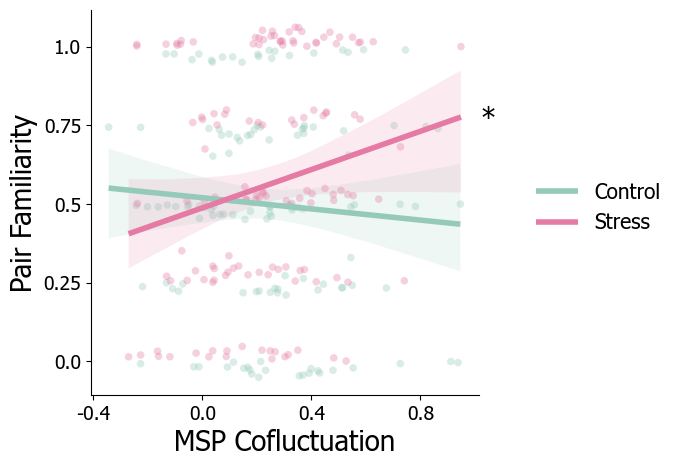

In [19]:
np.random.seed(0)

cond = "A"
use_model_lme = ets_famil_model_lme
    
groups = ["Control", "Stress"]
palette = group_colors

viz_df = ets_famil_df_c[["subid", "group", "pairnum", "familacc", f"ets"]]
viz_df["familacc_place"] = viz_df["familacc"].apply(lambda x: x*4)
viz_df = viz_df.sort_values(by="group")

ets_ranges = {}
for group in groups:
    cur_df = viz_df[viz_df["group"] == group]
    ets_ranges[group] = [np.min(cur_df[f"ets"]), np.max(cur_df[f"ets"])]

group_data = []
for group in groups:
    grp_df = viz_df[viz_df["group"] == group]
    grp_ets_range = ets_ranges[group]

    new_data_grp = pd.DataFrame({"group": np.repeat([group], 10), "ets": np.linspace(grp_ets_range[0], grp_ets_range[1], 10)})
    group_data.append(new_data_grp)

group_data = pd.concat(group_data).reset_index(drop=True)

# convert data to R
with (ro.default_converter + pandas2ri.converter).context():
    r_group_data = ro.conversion.get_conversion().py2rpy(group_data)

predict = rstats.predict(use_model_lme, newdata=r_group_data, level=0)

# convert back to Python
with (ro.default_converter + pandas2ri.converter).context():
    grp_predict = ro.conversion.get_conversion().rpy2py(predict)

group_data["predict"] = grp_predict

###################################
# Visualize
###################################
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
col = 'ets'

for groupi, group in zip(np.arange(len(groups)), groups):
    CIs = pd.read_csv(f'./midpoints/cofluctuation/pairwise_ets_famil_CI_{group}_{cond}_{roiname}_9999_usebackgroundTrue.csv')
    ax.fill_between(CIs[col], CIs["CI_min"], CIs["CI_max"], color=group_colors[groupi], edgecolor="None", alpha=0.15)
    ax.plot(group_data[group_data["group"] == group][col], group_data[group_data["group"] == group]["predict"], color=group_colors[groupi], linewidth=4, solid_capstyle="butt", label=group)
    
    cur_data = viz_df.loc[(viz_df["group"] == group)]

    cur_x = []
    cur_y = []

    for familacc in np.unique(cur_data["familacc"]): #np.arange(0, 1.01, 0.25):
        cur_data_famil = cur_data[cur_data["familacc"] == familacc]
        cur_data_famil_x = cur_data_famil[col]
        
        kde = scipy.stats.gaussian_kde(cur_data_famil_x)
        density = kde(cur_data_famil_x)     # estimate the local density at each datapoint
    
        # generate some random jitter between 0 and 1
        yvals = density*np.random.rand(len(cur_data_famil))*0.075*(groupi-0.5) + familacc

        cur_y += list(yvals)
        cur_x += list(cur_data_famil_x)
    
    ax.scatter(x=cur_x, y=cur_y, color=palette[groupi], s=30, edgecolor="None", alpha=0.35)

    # add sig stars
    sig_df = group_data.loc[(group_data["group"] == group)]
    starx = np.max(sig_df[col]) + np.diff(ax.get_xlim())*0.05
    stary = float(sig_df[sig_df[col] == np.max(sig_df[col])]["predict"])
    pval = group2sigs[f'{group}']
    star = pval2star(pval)

    if pval <= 0.05:
        ax.text(x=starx, y=stary, s=star, color='k', fontsize=20, horizontalalignment='left', verticalalignment='center_baseline')
    elif pval <= 0.051:
        ax.text(x=starx, y=stary, s='~', color='k', fontsize=16, horizontalalignment='center', verticalalignment='top')

ax.set_ylabel("Pair Familiarity", fontsize=20)
ax.set_xlabel(f"{roiname} Cofluctuation", fontsize=20)

xtickn = 0.4
ax.set_xticks(np.arange(xtickn*math.ceil(ax.get_xlim()[0]/xtickn), ax.get_xlim()[1], xtickn))
ax.set_xticklabels([f'{i:.1f}' for i in np.arange(xtickn*math.ceil(ax.get_xlim()[0]/xtickn), ax.get_xlim()[1], xtickn)], fontsize=14)
ax.set_yticks(np.linspace(0, 1, 5))
ax.set_yticklabels(np.linspace(0, 1, 5), fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.1, 0.6), frameon=False)
sns.despine()
plt.show()


## 7. Relationship between background connectivity during learning and average pair familiarity across subjects

In [20]:
def bg_corr_connectivity(subIDs, runs, roi1, roi2):
    """
    Computes correlation between background activity in 2 ROIs for a list of subjects.
    Args:
        subIDs (list(int)): list of subject IDs
        runs (list(string)): list of run names
        roi1 (string): first ROI label
        roi2 (string): second ROI label
        
    Returns:
        list(floats): list of connectivity correlations
    """
    bgconn = []
    
    for s in range(len(subIDs)):
        full_timeseries1 = []
        full_timeseries2 = []

        run_r = []
        
        for r in runs:
            subid = subIDs[s]

            series1 = load_avg_backgroundresids(subid, r, roi1, norm=False)
            series2 = load_avg_backgroundresids(subid, r, roi2, norm=False)

            # get average timeseries over voxels and append to full timeseries
            full_timeseries1.append(series1)
            full_timeseries2.append(series2)

            run_r.append(np.corrcoef(series1, series2)[0, 1])
        
        full_timeseries1 = np.concatenate(full_timeseries1)
        full_timeseries2 = np.concatenate(full_timeseries2)
        
        r = np.corrcoef(full_timeseries1, full_timeseries2)[0, 1]
        
        # Fisher r-to-z transform
        bgconn.append(np.arctanh(r))
        
    return bgconn
        

In [21]:
# calculate subject-level background connectivity over learning runs between a given pair of ROIs
overwrite = True
prelearn_runs = ["scene1"]
learn_runs = ["scene2", "scene3", "scene4"]
rois = ["CA1", "EC"]

roi1, roi2 = sorted(rois)
learn_bgconn = np.array(bg_corr_connectivity(subIDs, learn_runs, roi1, roi2))
prelearn_bgconn = np.array(bg_corr_connectivity(subIDs, prelearn_runs, roi1, roi2))
baselined_bgconn = learn_bgconn - prelearn_bgconn

out_csv = f'./midpoints/summary/BgConn_{roi1}_{roi2}_{"".join(learn_runs).replace("scene", "")}.csv'

if not os.path.isfile(out_csv) or overwrite:
    bgconn_df = pd.DataFrame({"subID": subIDs, "bg_connectivity": baselined_bgconn})
    bgconn_df.to_csv(out_csv, index=False)
else:
    bgconn_df = pd.read_csv(out_csv)
    

### Continuous Version (Supplemental Figure S6B left)

Control:
r=-0.26366214603069377
95% CI [-0.5188934024685647, 0.019234130462403545]; p=0.06840684068406841

Stress:
r=0.2611029870149658
95% CI [0.037675032993463184, 0.4716069148498626]; p=0.0232023202320232



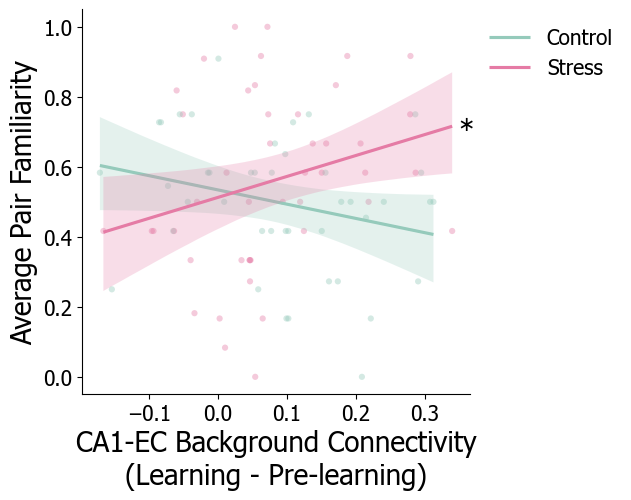

In [22]:
np.random.seed(0)

famil_df = pd.read_csv("./midpoints/behavior/behav_famil.csv")
bgc_famil_df = pd.merge(bgconn_df, famil_df, on="subID", how="left").dropna()

ax = plot_lm(df=bgc_famil_df, xvar="bg_connectivity", yvar="familacc", groups=groups, figsize=(5, 5),
             pretty=True, legend=True, boot=True, verbose=False)
ax.set_xlabel("CA1-EC Background Connectivity\n(Learning - Pre-learning)", fontsize=20)
ax.set_ylabel("Average Pair Familiarity", fontsize=20)

plt.show()


### Binarized version (Supplemental Figure S6B right)

Control above vs below chance: 95% CI [-0.14313952263249666, 0.0062570479544056526]; p=0.07048070480704807; r=0.4013157894736843
Stress above vs below chance: 95% CI [0.026766397658704474, 0.15673527640272306]; p=0.007660076600766007; r=-0.5447570332480818
Control vs stress below chance: 95% CI [-0.1632039381161177, -0.01836239010591443]; p=0.016100161001610016; r=0.6102941176470589
Control vs stress above chance: 95% CI [0.002889524388382166, 0.13643359433897823]; p=0.04148041480414804; r=-0.3546910755148741
Adjusted R-squared [1] 0.09260914

                   Df    Sum Sq   Mean Sq    F value    Pr(>F)
familchance         1  0.005079  0.005079   0.415673  0.521182
group               1  0.000081  0.000081   0.006658  0.935199
familchance:group   1  0.123786  0.123786  10.130176  0.002165
Residuals          71  0.867588  0.012220        NaN       NaN
                   partial.etasq  statistic
familchance                0.006      0.416
group                      0.000      0.007
fam

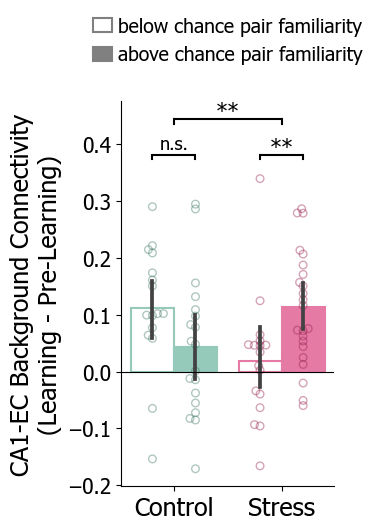

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(2.75, 5))
groups = ["Control", "Stress"]
chancevals = ["below", "above"]

bgc_famil_df_bin = bgc_famil_df.copy()
bgc_famil_df_bin["familchance"] = bgc_famil_df_bin["familacc"].apply(threewaysplit)
bgc_famil_df_bin = bgc_famil_df_bin[bgc_famil_df_bin["familchance"] != "chance"]

sns.barplot(ax=ax, data=bgc_famil_df_bin, x="group", y="bg_connectivity", hue="familchance", order=groups, hue_order=chancevals)
sns.swarmplot(ax=ax, data=bgc_famil_df_bin, x="group", y="bg_connectivity", hue="familchance", palette="mako", order=groups, hue_order=chancevals, dodge=True, alpha=0, s=4)

# add pointstyle
for groupi in range(len(groups)):
    for famili in range(len(chancevals)):
        i = groupi*len(chancevals) + famili
        x_data, y_data = ax.collections[i].get_offsets().T

        ax.scatter(x_data, y_data, color="None", s=30, alpha=0.4, edgecolor=dark_group_colors[groupi], linewidth=1)

# add barstyle
for i, bar in enumerate(ax.patches):
    if i < len(groups)*len(chancevals):
        #bar.set_hatch(hatches[i//len(groups)])
        if i//len(groups) == 0:
            bar.set_color('white')
        else:
            bar.set_color(group_colors[i%len(groups)])
        bar.set_edgecolor(group_colors[i%len(groups)])
        bar.set_linewidth(1.5)

# define legend elements
legend_elements = [Patch(facecolor="white", edgecolor='gray', linewidth=1.5, label='below chance pair familiarity'), 
                   Patch(facecolor="gray", edgecolor='gray', linewidth=1.5, label='above chance pair familiarity')]

ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.05), frameon=False, handlelength=1, handletextpad=0.3, columnspacing=1, fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("CA1-EC Background Connectivity\n(Learning - Pre-Learning)")
sns.despine()


##############################
# compute significance
##############################
np.random.seed(0)
barxs = np.array([line.get_data()[0][0] for line in ax.get_lines()[:4]]).reshape((2, 2)).T
stary_lvl1 = np.max(bgc_famil_df_bin["bg_connectivity"])
yshift = np.diff(ax.get_ylim())[0]*0.075

# individual group comparisons
for groupi, group in zip(np.arange(len(groups)), groups):
    grp_df = bgc_famil_df_bin[bgc_famil_df_bin["group"] == group]
    belowchance_MSP = np.array(grp_df[grp_df["familchance"] == "below"]["bg_connectivity"])
    abovechance_MSP = np.array(grp_df[grp_df["familchance"] == "above"]["bg_connectivity"])

    CI, p = simple_bootstrap_2group(abovechance_MSP, belowchance_MSP, iterations=99999)
    p = p*2
    rbc = mannwhitneyu_effsize(belowchance_MSP, abovechance_MSP, alternative="two-sided", verbose=False)

    print(f"{group} above vs below chance: 95% CI {CI}; p={p}; r={rbc}")

    linex = barxs[groupi]
    stary = stary_lvl1 + yshift

    if p <= 0.05:
        star = pval2star(p)
        fontsize=16
        vadjust=0
    else:
        star = 'n.s.'
        fontsize=13
        vadjust=0.01
        
    ax.text(s=star, x=np.mean(linex), y=stary+vadjust, fontsize=fontsize, color='k', ha='center')
    ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1.5)
    ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1.5)
    ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1.5)
    

for chance in ["below", "above"]:
    ctrl_chance =  np.array(bgc_famil_df_bin[(bgc_famil_df_bin["familchance"] == chance) & (bgc_famil_df_bin["group"] == "Control")]["bg_connectivity"])
    stress_chance =  np.array(bgc_famil_df_bin[(bgc_famil_df_bin["familchance"] == chance) & (bgc_famil_df_bin["group"] == "Stress")]["bg_connectivity"])
    CI, p = simple_bootstrap_2group(stress_chance, ctrl_chance, iterations=99999)
    p = p*2
    rbc = mannwhitneyu_effsize(ctrl_chance, stress_chance, alternative="two-sided", verbose=False)
    
    print(f"Control vs stress {chance} chance: 95% CI {CI}; p={p}; r={rbc}")

rstats = importr('stats')
base = importr('base')
sjstats = importr('sjstats')

with (ro.default_converter + pandas2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(bgc_famil_df_bin)
lm_model = rstats.lm(data=r_data, formula="bg_connectivity ~ familchance * group")

with (ro.default_converter + pandas2ri.converter).context():
    lm_summary = ro.conversion.get_conversion().rpy2py(rstats.anova(lm_model))
    effsize = ro.conversion.get_conversion().rpy2py(sjstats.anova_stats(model=lm_model))[["partial.etasq", "statistic"]]

interactp = lm_summary["Pr(>F)"]["familchance:group"]

if interactp <= 0.05:
    linex = np.mean(barxs, axis=1)
    stary = stary_lvl1 + yshift*2.5
    star = pval2star(interactp)

    ax.text(s=star, x=np.mean(linex), y=stary, fontsize=16, color='k', ha='center')
    ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1.5)
    ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1.5)
    ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1.5)

print("Adjusted R-squared", base.summary(lm_model)[-3])
print(lm_summary)
print(effsize)

ax.axhline(0, color='k', linewidth=0.8)
plt.xticks(fontsize=18)

plt.show()
